# Can One Notebook Model Curves, Retinas, Flows, and Sketches with GANs?

## What does the environment need before anything runs?

The install cell follows the `try import / except install` pattern so it is safe in Colab. If a package cannot be installed (for example when offline) the notebook falls back to functionality that does not need it.

In [1]:
# Imports with a safe pip-install fallback in the except branch (Colab).
import sys, subprocess

def _ensure(pkg, import_name=None):
    """Import a package, attempting a quiet pip install if it is missing."""
    name = import_name or pkg
    try:
        return __import__(name)
    except Exception:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], timeout=180)
            return __import__(name)
        except Exception as exc:
            print("Could not import or install %s: %s" % (pkg, exc))
            return None

import os, math, json, urllib.request, io
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

# Optional packages. Missing ones trigger labelled fallbacks later.
pd = _ensure("pandas")
_sk = _ensure("scikit-learn", "sklearn")
if _sk is not None:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
_tm = _ensure("torchmetrics")
_scipy = _ensure("scipy")

print("torch version:", torch.__version__)
print("numpy version:", np.__version__)

torch version: 2.11.0+cu128
numpy version: 2.0.2


## How is reproducibility fixed across every experiment?

Configuration is kept separate from model logic. Seeds are fixed for Python, NumPy and PyTorch. The Part 1 sine baseline uses the tutorial seed of 42 exactly. All other experiments use a documented project seed.

In [2]:
QUICK_MODE = False  # set to False to reproduce the full runs in the report.

PROJECT_SEED = 2028  # documented global seed for this notebook's own experiments.
SINE_BASELINE_SEED = 42  # fixed by the guided tutorial for Part 1 baseline.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Output directories for checkpoints, figures and metrics.
OUT_DIR = "outputs"
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MET_DIR = os.path.join(OUT_DIR, "metrics")
for _d in (OUT_DIR, CKPT_DIR, FIG_DIR, MET_DIR):
    os.makedirs(_d, exist_ok=True)

# Central config. Epoch counts and sample sizes shrink in QUICK_MODE.
CONFIG = {
    "quick_mode": QUICK_MODE,
    "project_seed": PROJECT_SEED,
    "part1": {
        "n_points": 1024,
        "batch_size": 32,
        "lr": 1e-3,
        "epochs": 40 if QUICK_MODE else 2000,
        "eval_samples": 1000,
        "latent_dim": 2,
    },
    "image_gan": {
        "image_size": 28,
        "latent_dim": 64,
        "batch_size": 128,
        "lr": 2e-4,
        "beta1": 0.5,
        "epochs": 2 if QUICK_MODE else 40,
        "max_train": 1024 if QUICK_MODE else 20000,
        "fid_samples": 256 if QUICK_MODE else 2048,
    },
    "cicids": {
        "latent_dim": 32,
        "batch_size": 128,
        "lr": 2e-4,
        "epochs": 3 if QUICK_MODE else 120,
        "max_per_class": 1500 if QUICK_MODE else 20000,
        "eval_samples": 2000,
    },
}

def set_seed(seed):
    """Fix seeds for Python, NumPy and PyTorch for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(PROJECT_SEED)
with open(os.path.join(MET_DIR, "config.json"), "w") as _f:
    json.dump(CONFIG, _f, indent=2)
print("Configuration saved. QUICK_MODE =", QUICK_MODE)

Using device: cuda
Configuration saved. QUICK_MODE = False


In [3]:
# Outputs persist to the repo-relative 'outputs' folder created above, holding
# figures, metrics and checkpoints. Keeping every artifact inside the project tree
# means a re-run reproduces the report figures and numbers from version controlled
# paths without depending on any external mount.
for _d in (OUT_DIR, CKPT_DIR, FIG_DIR, MET_DIR):
    os.makedirs(_d, exist_ok=True)
print("Outputs persist to repo-relative folder:", OUT_DIR)


Outputs persist to repo-relative folder: outputs


## Which helpers are shared by all four tasks?

These helpers are reused by every task: a non-finite loss guard that fails loudly, checkpoint save and load with metadata, a version-robust matrix square root using a symmetric eigendecomposition, a Frechet distance in a fixed feature space used as an offline FID proxy, an energy distance for the 2D experiments, and small plotting utilities. Identical preprocessing is applied to real and generated data at evaluation time.

In [4]:
def check_finite(value, name):
    """Raise loudly if a loss or tensor is not finite, to stop silent divergence."""
    v = float(value)
    if not math.isfinite(v):
        raise FloatingPointError("Non-finite value detected for %s: %s" % (name, v))
    return v

def save_checkpoint(model, path, meta):
    """Save model weights together with a metadata dictionary."""
    torch.save({"state_dict": model.state_dict(), "meta": meta}, path)
    return path

def load_state_into(model, path):
    """Reload weights from a checkpoint into a fresh model instance."""
    blob = torch.load(path, map_location=DEVICE)
    model.load_state_dict(blob["state_dict"])
    model.eval()
    return blob.get("meta", {})

def sqrtm_psd(mat):
    """Symmetric PSD matrix square root via eigendecomposition (version robust)."""
    mat = 0.5 * (mat + mat.T)
    vals, vecs = torch.linalg.eigh(mat)
    vals = torch.clamp(vals, min=0.0)
    return (vecs * vals.sqrt()) @ vecs.T

def frechet_distance(feat_real, feat_fake, eps=1e-6):
    """Frechet distance between two feature sets modelled as Gaussians.

    Uses the identity tr(sqrtm(C1 C2)) = sum sqrt(eig(sqrtm(C1) C2 sqrtm(C1))) so
    that only symmetric eigendecompositions are required. This is version robust.
    """
    fr = feat_real.double()
    ff = feat_fake.double()
    mu1, mu2 = fr.mean(0), ff.mean(0)
    c1 = torch.cov(fr.T) + eps * torch.eye(fr.shape[1], dtype=torch.double)
    c2 = torch.cov(ff.T) + eps * torch.eye(ff.shape[1], dtype=torch.double)
    diff = mu1 - mu2
    s1 = sqrtm_psd(c1)
    inner = s1 @ c2 @ s1
    inner = 0.5 * (inner + inner.T)
    ev = torch.clamp(torch.linalg.eigvalsh(inner), min=0.0)
    trace_sqrt = ev.sqrt().sum()
    fid = (diff @ diff) + torch.trace(c1) + torch.trace(c2) - 2.0 * trace_sqrt
    return float(max(fid.item(), 0.0))

def energy_distance(x, y, max_n=800):
    """Sample energy distance between two 2D point sets. Symmetric and metric."""
    rng = np.random.default_rng(PROJECT_SEED)  # deterministic subsample for reproducibility
    def _sub(a):
        if a.shape[0] > max_n:
            idx = rng.choice(a.shape[0], max_n, replace=False)
            return a[idx]
        return a
    x = _sub(np.asarray(x, dtype=np.float64))
    y = _sub(np.asarray(y, dtype=np.float64))
    def _pdist_mean(a, b):
        d = np.sqrt(((a[:, None, :] - b[None, :, :]) ** 2).sum(-1) + 1e-12)
        return d.mean()
    return float(2 * _pdist_mean(x, y) - _pdist_mean(x, x) - _pdist_mean(y, y))

def save_fig(fig, name):
    """Save a figure to the figure directory and also show it inline."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("Saved figure:", path)
    return path

print("Helper functions ready.")

Helper functions ready.


## Why use a fixed random feature extractor for the offline FID proxy?

A fixed random convolutional feature extractor is defined once and reused for the offline FID proxy on both image tasks. Its weights are seeded, so the proxy is deterministic. The offline proxy is not the ImageNet Inception FID; it is a feature-space Frechet distance used only when the true metric cannot be computed (for example offline). Values from the proxy and from the true Inception FID are on different scales and are never compared with each other.

In [5]:
class FixedFeatureNet(nn.Module):
    """Deterministic random weight CNN used as an offline FID proxy extractor."""
    def __init__(self, seed=1234):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.c1 = nn.Conv2d(1, 16, 3, 2, 1)
        self.c2 = nn.Conv2d(16, 32, 3, 2, 1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        for p in self.parameters():
            p.data = torch.randn(p.shape, generator=g) * 0.3
            p.requires_grad_(False)
    def forward(self, x):
        x = torch.relu(self.c1(x))
        x = torch.relu(self.c2(x))
        return self.pool(x).flatten(1)

_FEATURE_NET = FixedFeatureNet().to(DEVICE).eval()

def proxy_features(images):
    """Return fixed CNN features for a batch of 1 channel images in [-1, 1]."""
    with torch.no_grad():
        return _FEATURE_NET(images.to(DEVICE)).cpu()

USE_TRUE_FID = not QUICK_MODE

def image_fid(real_imgs, fake_imgs, chunk=256):
    """Compute FID for 1 channel images in [-1, 1]. Returns (value, label).

    In full runs the true Inception FID is required: if torchmetrics is missing the
    call raises instead of silently substituting a weaker metric. Images are fed to
    the metric in chunks to bound memory. In QUICK_MODE a clearly labelled offline
    proxy is used only for a fast smoke test and is never reported as Inception FID.
    """
    if USE_TRUE_FID:
        if _tm is None:
            raise RuntimeError(
                "torchmetrics is required for the true Inception FID in a full run. "
                "Install torchmetrics[image] and torch-fidelity, then re-run.")
        from torchmetrics.image.fid import FrechetInceptionDistance
        fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
        def _feed(imgs, is_real):
            for s in range(0, imgs.shape[0], chunk):
                batch = imgs[s:s + chunk].clamp(-1, 1)
                batch = ((batch + 1) / 2.0).repeat(1, 3, 1, 1).to(DEVICE)
                fid.update(batch, real=is_real)
        _feed(real_imgs, True)
        _feed(fake_imgs, False)
        return float(fid.compute().item()), "true Inception FID (torchmetrics, feature 2048)"
    fr = proxy_features(real_imgs)
    ff = proxy_features(fake_imgs)
    return frechet_distance(fr, ff), "offline FID proxy (fixed CNN, QUICK_MODE smoke test only)"

print("FID helpers ready. USE_TRUE_FID =", USE_TRUE_FID)


FID helpers ready. USE_TRUE_FID = True


## Can a GAN learn a 2D distribution from scratch?

## Does the sine baseline reproduce the guided tutorial exactly?

This reproduces the guided tutorial exactly: seed 42, 1024 pairs with x uniform on [0, 2 pi] and y = sin(x), shuffled batches of 32, the tutorial discriminator (2 -> 256 -> 128 -> 64 -> 1 with ReLU, dropout 0.3 after each hidden layer and a sigmoid output), the tutorial generator (latent 2 -> 16 -> 32 -> 2 with ReLU and no dropout), binary cross entropy, Adam with learning rate 1e-3 and 2000 epochs, and a 1000 sample evaluation. Documented tutorial corrections are applied and are listed in the markdown cell that follows the training loop; they improve correctness and robustness but do not change the intended baseline experiment.

In [6]:
def make_sine_data(n):
    """Tutorial sine data: x uniform on [0, 2 pi], y = sin(x)."""
    train_data = torch.zeros((n, 2))
    train_data[:, 0] = 2.0 * math.pi * torch.rand(n)
    train_data[:, 1] = torch.sin(train_data[:, 0])
    labels = torch.zeros(n)
    return train_data, labels

class SineDiscriminator(nn.Module):
    """Tutorial discriminator: MLP 2 -> 256 -> 128 -> 64 -> 1 with dropout 0.3."""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.model(x)

class BaselineGenerator(nn.Module):
    """Tutorial generator: MLP latent 2 -> 16 -> 32 -> 2 with ReLU and no dropout."""
    def __init__(self, latent_dim=2, out_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, out_dim),
        )
    def forward(self, x):
        return self.model(x)

In [7]:
def train_2d_gan(train_data, generator, discriminator, cfg, seed, log_name):
    """Train a 2D GAN and return per-epoch loss history.

    Applies the documented tutorial corrections:
      1. label and latent batch sizes use the current batch length real.shape[0];
      2. the generator output is detached during the discriminator update;
      3. the discriminator optimiser is not stepped during the generator update
         (discriminator gradients are frozen for that step and restored after);
      4. logging is epoch level, not tied to a fragile batch index;
      5. non-finite losses fail loudly.
    """
    set_seed(seed)
    labels = torch.zeros(train_data.shape[0])
    train_set = [(train_data[i], labels[i]) for i in range(train_data.shape[0])]
    loader = torch.utils.data.DataLoader(train_set, batch_size=cfg["batch_size"], shuffle=True)

    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)
    loss_fn = nn.BCELoss()
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=cfg["lr"])
    opt_g = torch.optim.Adam(generator.parameters(), lr=cfg["lr"])
    latent_dim = cfg["latent_dim"]

    hist = {"epoch": [], "loss_d": [], "loss_g": []}
    for epoch in range(cfg["epochs"]):
        ld = lg = 0.0
        nb = 0
        for real_samples, _ in loader:
            real_samples = real_samples.to(DEVICE)
            bs = real_samples.shape[0]  # correction 1: current batch length
            real_labels = torch.ones((bs, 1), device=DEVICE)
            fake_labels = torch.zeros((bs, 1), device=DEVICE)

            # Discriminator update. Correction 2: detach generator output.
            z = torch.randn((bs, latent_dim), device=DEVICE)
            fake = generator(z).detach()
            discriminator.zero_grad()
            all_x = torch.cat((real_samples, fake))
            all_y = torch.cat((real_labels, fake_labels))
            out_d = discriminator(all_x)
            loss_d = loss_fn(out_d, all_y)
            loss_d.backward()
            opt_d.step()

            # Generator update. Correction 3: freeze D grads, do not step opt_d.
            for p in discriminator.parameters():
                p.requires_grad_(False)
            z = torch.randn((bs, latent_dim), device=DEVICE)
            generator.zero_grad()
            gen = generator(z)
            out_dg = discriminator(gen)
            loss_g = loss_fn(out_dg, torch.ones((bs, 1), device=DEVICE))
            loss_g.backward()
            opt_g.step()
            for p in discriminator.parameters():
                p.requires_grad_(True)

            ld += check_finite(loss_d, "loss_d")
            lg += check_finite(loss_g, "loss_g")
            nb += 1
        hist["epoch"].append(epoch)
        hist["loss_d"].append(ld / nb)
        hist["loss_g"].append(lg / nb)
        if epoch % max(1, cfg["epochs"] // 5) == 0 or epoch == cfg["epochs"] - 1:
            print("[%s] epoch %d loss_d %.4f loss_g %.4f" % (log_name, epoch, ld / nb, lg / nb))
    return generator, discriminator, hist

In [8]:
# Train the sine baseline with the exact tutorial seed of 42.
torch.manual_seed(42)  # exact tutorial call for the Part 1 baseline (P1-01).
sine_data, _ = make_sine_data(CONFIG["part1"]["n_points"])
sine_gen = BaselineGenerator(latent_dim=2, out_dim=2)
sine_disc = SineDiscriminator()
sine_gen, sine_disc, sine_hist = train_2d_gan(
    sine_data, sine_gen, sine_disc, CONFIG["part1"], seed=SINE_BASELINE_SEED, log_name="sine")

# Save checkpoint and losses (P1-06).
save_checkpoint(sine_gen, os.path.join(CKPT_DIR, "part1_sine_generator.pt"),
                {"task": "part1_sine", "seed": SINE_BASELINE_SEED, "config": CONFIG["part1"]})
np.savez(os.path.join(MET_DIR, "part1_sine_losses.npz"), **{k: np.array(v) for k, v in sine_hist.items()})
print("Sine baseline trained and checkpoint saved.")

/tmp/ipykernel_1566/2239702873.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  v = float(value)


[sine] epoch 0 loss_d 0.4167 loss_g 0.9437
[sine] epoch 400 loss_d 0.6750 loss_g 0.7885
[sine] epoch 800 loss_d 0.6462 loss_g 0.8344
[sine] epoch 1200 loss_d 0.6302 loss_g 0.8211
[sine] epoch 1600 loss_d 0.6155 loss_g 0.8119
[sine] epoch 1999 loss_d 0.6228 loss_g 0.8756
Sine baseline trained and checkpoint saved.


Saved figure: outputs/figures/part1_sine_baseline.png


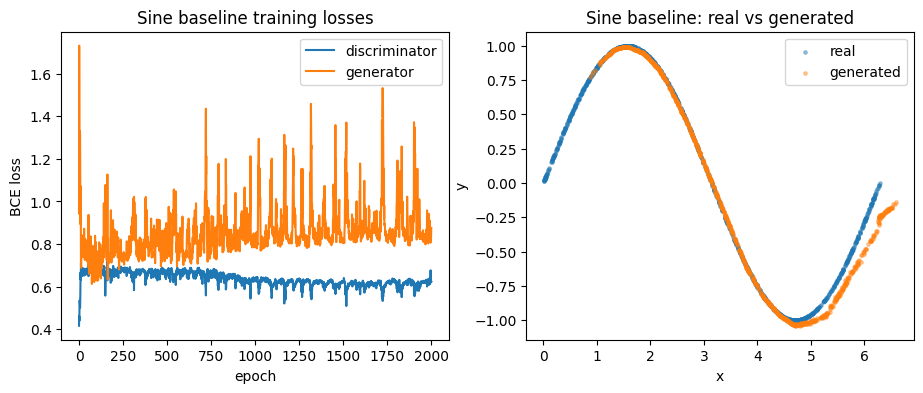

In [9]:
# Evaluate the sine baseline with 1000 generated samples and compare visually (P1-04).
set_seed(SINE_BASELINE_SEED)
sine_gen.eval()
with torch.no_grad():
    z = torch.randn(CONFIG["part1"]["eval_samples"], 2, device=DEVICE)
    sine_fake = sine_gen(z).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sine_hist["epoch"], sine_hist["loss_d"], label="discriminator")
ax[0].plot(sine_hist["epoch"], sine_hist["loss_g"], label="generator")
ax[0].set_title("Sine baseline training losses")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE loss"); ax[0].legend()
ax[1].scatter(sine_data[:, 0], sine_data[:, 1], s=6, alpha=0.4, label="real")
ax[1].scatter(sine_fake[:, 0], sine_fake[:, 1], s=6, alpha=0.4, label="generated")
ax[1].set_title("Sine baseline: real vs generated")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y"); ax[1].legend()
save_fig(fig, "part1_sine_baseline.png")
plt.show()

## Which tutorial-loop corrections are applied in every training loop?

1. Label and latent batch sizes use the current batch length `real_samples.shape[0]` instead of assuming every batch equals 32. The tutorial happens to work only because 1024 divides evenly into 32 batches of 32.
2. The generator output is detached during the discriminator update so discriminator backpropagation does not accumulate generator gradients.
3. During the generator update the discriminator optimiser is not stepped; discriminator gradients are frozen for that step and restored afterwards.
4. Logging is epoch level rather than the fragile `n == batch_size - 1` condition.
5. Non-finite losses raise an error immediately rather than training silently on diverged values.

The baseline architecture, data distribution, seed, optimiser family, learning rate, epoch count and evaluation sample count all match the tutorial. Seed sensitivity is discussed with the results.

## Does a ring of eight Gaussians expose mode collapse better than a sine curve?

I chose a mixture of eight Gaussians arranged on a circle. The sine curve is a single-valued function, so a generator only has to learn one thin manifold. A ring of separated Gaussian modes is multi-modal, so it directly probes mode coverage and the well-known GAN failure of mode collapse, where the generator captures only a subset of the modes. This makes the later architecture comparison more informative than repeating a single curve. The choice is my own design decision for this task.

Saved figure: outputs/figures/part1_ring_target.png


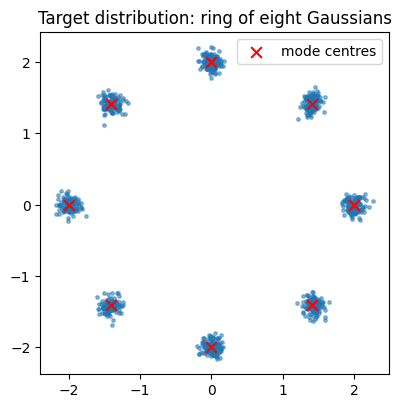

In [10]:
def make_ring_of_gaussians(n, n_modes=8, radius=2.0, std=0.08, seed=PROJECT_SEED):
    """Sample a 2D mixture of Gaussians whose means lie on a circle."""
    set_seed(seed)
    angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    comp = np.random.randint(0, n_modes, size=n)
    pts = centers[comp] + std * np.random.randn(n, 2)
    return torch.tensor(pts, dtype=torch.float32), centers

ring_data, ring_centers = make_ring_of_gaussians(CONFIG["part1"]["n_points"])
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(ring_data[:, 0], ring_data[:, 1], s=6, alpha=0.5)
ax.scatter(ring_centers[:, 0], ring_centers[:, 1], marker="x", c="red", s=60, label="mode centres")
ax.set_title("Target distribution: ring of eight Gaussians")
ax.set_aspect("equal"); ax.legend()
save_fig(fig, "part1_ring_target.png")
plt.show()

## Does the modified generator cover more modes than the baseline?

The comparison holds everything fixed except the generator architecture. Both generators are trained on the same ring data, with the same project seed, the same Adam optimiser, the same learning rate, the same epoch count and the same evaluation sample count. Only the generator architecture varies.

- Baseline generator: the tutorial generator, latent 2 -> 16 -> 32 -> 2 with ReLU.
- Modified generator: LeakyReLU(0.2) activations and one extra hidden layer, latent 2 -> 32 -> 64 -> 64 -> 2.

Plain ReLU can leave units permanently inactive ("dead ReLU"), which limits how many separated modes a small generator can reach. LeakyReLU keeps a non-zero gradient for negative pre-activations, and the extra hidden layer adds capacity to place mass on several separated modes. The hypothesis is that the modified generator covers more of the eight modes and achieves a lower distribution distance. The quantitative metric is the energy distance between real and generated samples (lower is better), plus the number of modes covered, where a mode counts as covered if at least one percent of generated points fall nearest to it. The energy distance is a proper distance between distributions and does not need a matrix square root.

In [11]:
class ModifiedGenerator(nn.Module):
    """Modified generator: LeakyReLU and one extra hidden layer (2 -> 32 -> 64 -> 64 -> 2)."""
    def __init__(self, latent_dim=2, out_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, out_dim),
        )
    def forward(self, x):
        return self.model(x)

def modes_covered(fake, centers, frac=0.01):
    """Count mode centres that receive at least frac of the generated points."""
    d = np.sqrt(((fake[:, None, :] - centers[None, :, :]) ** 2).sum(-1))
    nearest = d.argmin(1)
    counts = np.bincount(nearest, minlength=centers.shape[0])
    return int((counts >= frac * fake.shape[0]).sum()), counts

def run_ring_experiment(generator, tag):
    """Train a generator on the ring data and return generated samples and metrics."""
    disc = SineDiscriminator()  # identical discriminator for both arms.
    gen, disc, hist = train_2d_gan(ring_data, generator, disc, CONFIG["part1"],
                                   seed=PROJECT_SEED, log_name=tag)
    save_checkpoint(gen, os.path.join(CKPT_DIR, "part1_ring_%s_generator.pt" % tag),
                    {"task": "part1_ring_%s" % tag, "seed": PROJECT_SEED})
    set_seed(PROJECT_SEED)
    gen.eval()
    with torch.no_grad():
        z = torch.randn(CONFIG["part1"]["eval_samples"], 2, device=DEVICE)
        fake = gen(z).cpu().numpy()
    ed = energy_distance(ring_data.numpy(), fake)
    nmodes, counts = modes_covered(fake, ring_centers)
    return {"gen": gen, "hist": hist, "fake": fake, "energy": ed,
            "modes": nmodes, "counts": counts}

res_base = run_ring_experiment(BaselineGenerator(2, 2), "baseline_arch")
res_mod = run_ring_experiment(ModifiedGenerator(2, 2), "modified_arch")

[baseline_arch] epoch 0 loss_d 0.4452 loss_g 0.8721
[baseline_arch] epoch 400 loss_d 0.5494 loss_g 1.4829
[baseline_arch] epoch 800 loss_d 0.5492 loss_g 1.2842
[baseline_arch] epoch 1200 loss_d 0.4933 loss_g 1.3796
[baseline_arch] epoch 1600 loss_d 0.5443 loss_g 1.1552
[baseline_arch] epoch 1999 loss_d 0.5467 loss_g 1.0716
[modified_arch] epoch 0 loss_d 0.4641 loss_g 1.0048
[modified_arch] epoch 400 loss_d 0.5642 loss_g 1.1344
[modified_arch] epoch 800 loss_d 0.5755 loss_g 1.2079
[modified_arch] epoch 1200 loss_d 0.5758 loss_g 1.2938
[modified_arch] epoch 1600 loss_d 0.5588 loss_g 1.2778
[modified_arch] epoch 1999 loss_d 0.5647 loss_g 1.2087


Saved figure: outputs/figures/part1_arch_comparison.png


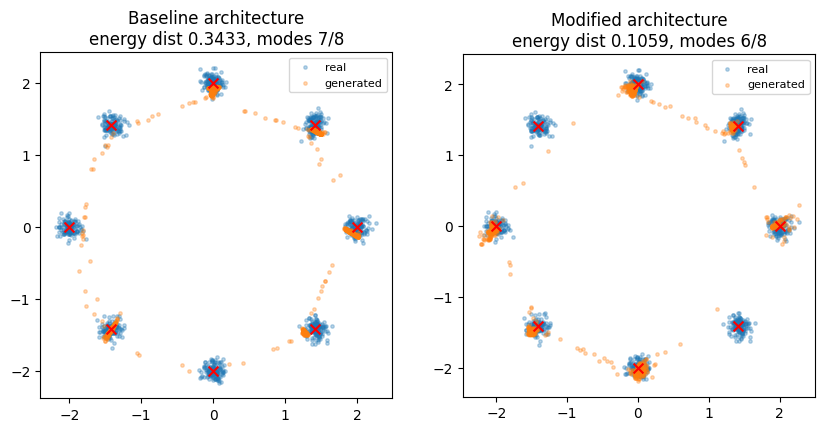

Part 1 architecture comparison (only the generator architecture differs):
{
  "baseline": {
    "energy_distance": 0.34330724871981877,
    "modes_covered": 7
  },
  "modified": {
    "energy_distance": 0.10585718271151467,
    "modes_covered": 6
  }
}


In [12]:
# Visual and quantitative comparison of the two architectures (P1-04, P1-05).
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, res, title in ((ax[0], res_base, "Baseline architecture"),
                      (ax[1], res_mod, "Modified architecture")):
    a.scatter(ring_data[:, 0], ring_data[:, 1], s=6, alpha=0.3, label="real")
    a.scatter(res["fake"][:, 0], res["fake"][:, 1], s=6, alpha=0.3, label="generated")
    a.scatter(ring_centers[:, 0], ring_centers[:, 1], marker="x", c="red", s=50)
    a.set_title("%s\nenergy dist %.4f, modes %d/8" % (title, res["energy"], res["modes"]))
    a.set_aspect("equal"); a.legend(loc="upper right", fontsize=8)
save_fig(fig, "part1_arch_comparison.png")
plt.show()

comparison = {
    "baseline": {"energy_distance": res_base["energy"], "modes_covered": res_base["modes"]},
    "modified": {"energy_distance": res_mod["energy"], "modes_covered": res_mod["modes"]},
}
with open(os.path.join(MET_DIR, "part1_arch_comparison.json"), "w") as _f:
    json.dump(comparison, _f, indent=2)
print("Part 1 architecture comparison (only the generator architecture differs):")
print(json.dumps(comparison, indent=2))

## What does the Part 1 result actually show?

The two arms differ only in the generator architecture, so any difference in energy distance or mode coverage is attributable to that change. The measured values are printed above and saved to `part1_arch_comparison.json`; the report interprets the specific numbers from a full run. GAN training on separated modes is seed sensitive: with an unlucky seed either architecture can collapse onto a subset of modes, which is why the seed and full configuration are recorded and why mode coverage is reported alongside the distance.

## How is one convolutional GAN shared across both image tasks?

Both image tasks (OCTMNIST and QuickDraw) use one convolutional GAN definition, a DCGAN-style architecture for single-channel 28 by 28 images. Images are scaled to [-1, 1] and the generator uses a Tanh output so its range matches the data. Weights use the DCGAN initialisation. The same reusable training loop is used for both tasks and applies the same corrections as Part 1.

In [13]:
class DCGANGenerator(nn.Module):
    """DCGAN generator for 1 channel 28 by 28 images with a Tanh output."""
    def __init__(self, latent_dim, feat=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, feat * 2 * 7 * 7)
        self.feat = feat
        self.net = nn.Sequential(
            nn.BatchNorm2d(feat * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feat * 2, feat, 4, 2, 1),  # 7 -> 14
            nn.BatchNorm2d(feat),
            nn.ReLU(True),
            nn.ConvTranspose2d(feat, 1, 4, 2, 1),  # 14 -> 28
            nn.Tanh(),
        )
    def forward(self, z):
        x = self.fc(z).view(-1, self.feat * 2, 7, 7)
        return self.net(x)

class DCGANDiscriminator(nn.Module):
    """DCGAN discriminator for 1 channel 28 by 28 images with a sigmoid output."""
    def __init__(self, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, feat, 4, 2, 1), nn.LeakyReLU(0.2, True),  # 28 -> 14
            nn.Conv2d(feat, feat * 2, 4, 2, 1), nn.BatchNorm2d(feat * 2),
            nn.LeakyReLU(0.2, True),  # 14 -> 7
            nn.Flatten(),
            nn.Linear(feat * 2 * 7 * 7, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

def dcgan_weights_init(m):
    """DCGAN weight initialisation."""
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [14]:
def train_image_gan(images, cfg, seed, tag, n_progress=6):
    """Train the DCGAN on a tensor of images in [-1, 1]. Returns models and history.

    Saves fixed-noise progress grids across epochs so visual progress is comparable.
    Applies the same corrections as Part 1: current batch length, detached generator
    output in the discriminator step, no discriminator optimiser step during the
    generator update, epoch level logging and a non-finite loss guard.
    """
    set_seed(seed)
    latent_dim = cfg["latent_dim"]
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(images),
        batch_size=cfg["batch_size"], shuffle=True, drop_last=True)

    gen = DCGANGenerator(latent_dim).to(DEVICE)
    disc = DCGANDiscriminator().to(DEVICE)
    gen.apply(dcgan_weights_init)
    disc.apply(dcgan_weights_init)
    loss_fn = nn.BCELoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], 0.999))

    fixed_noise = torch.randn(36, latent_dim, device=DEVICE)
    hist = {"epoch": [], "loss_d": [], "loss_g": []}
    progress = []
    epochs = cfg["epochs"]
    save_epochs = sorted(set([0, epochs - 1] +
                             list(range(0, epochs, max(1, epochs // n_progress)))))
    for epoch in range(epochs):
        ld = lg = 0.0; nb = 0
        for (real,) in loader:
            real = real.to(DEVICE)
            bs = real.shape[0]  # correction 1
            # Discriminator step, generator output detached (correction 2).
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z).detach()
            disc.zero_grad()
            out_real = disc(real)
            out_fake = disc(fake)
            loss_d = loss_fn(out_real, torch.ones(bs, 1, device=DEVICE)) + \
                     loss_fn(out_fake, torch.zeros(bs, 1, device=DEVICE))
            loss_d.backward(); opt_d.step()
            # Generator step, do not step opt_d (correction 3).
            for p in disc.parameters():
                p.requires_grad_(False)
            z = torch.randn(bs, latent_dim, device=DEVICE)
            gen.zero_grad()
            out = disc(gen(z))
            loss_g = loss_fn(out, torch.ones(bs, 1, device=DEVICE))
            loss_g.backward(); opt_g.step()
            for p in disc.parameters():
                p.requires_grad_(True)
            ld += check_finite(loss_d, "loss_d"); lg += check_finite(loss_g, "loss_g"); nb += 1
        hist["epoch"].append(epoch); hist["loss_d"].append(ld / nb); hist["loss_g"].append(lg / nb)
        if epoch in save_epochs:
            gen.eval()
            with torch.no_grad():
                grid = gen(fixed_noise).cpu()
            gen.train()
            progress.append((epoch, grid))
        print("[%s] epoch %d loss_d %.4f loss_g %.4f" % (tag, epoch, ld / nb, lg / nb))
    save_checkpoint(gen, os.path.join(CKPT_DIR, "%s_generator.pt" % tag),
                    {"task": tag, "seed": seed, "latent_dim": latent_dim, "config": cfg})
    np.savez(os.path.join(MET_DIR, "%s_losses.npz" % tag),
             **{k: np.array(v) for k, v in hist.items()})
    return gen, disc, hist, progress, fixed_noise

def show_image_grid(imgs, title, fname, nrow=6):
    """Plot a grid of 1 channel images in [-1, 1]."""
    imgs = ((imgs.clamp(-1, 1) + 1) / 2).cpu().numpy()
    n = min(imgs.shape[0], nrow * nrow)
    fig, axes = plt.subplots(nrow, nrow, figsize=(nrow, nrow))
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        if i < n:
            ax.imshow(imgs[i, 0], cmap="gray", vmin=0, vmax=1)
    fig.suptitle(title)
    save_fig(fig, fname)
    plt.show()

print("Shared DCGAN ready.")

Shared DCGAN ready.


## Can a convolutional GAN reproduce retinal OCT texture?

## Where does OCTMNIST come from and how is it acquired?

OCTMNIST is part of the MedMNIST v2 collection (Yang et al., 2023). It contains 28 by 28 grayscale optical coherence tomography images of the retina in four classes, distributed under a Creative Commons Attribution 4.0 licence. The cell below tries the `medmnist` package first, then a direct download of the official `octmnist.npz`. If neither is reachable it builds a clearly labelled synthetic fallback so the notebook still runs; the fallback is never treated as the real dataset.

In [15]:
OCT_CLASS_NAMES = ["choroidal neovascularisation", "diabetic macular oedema",
                   "drusen", "normal"]

def load_octmnist(max_n):
    """Return (images_uint8 N,28,28, labels, source_label). Falls back to synthetic."""
    # Attempt 1: medmnist package.
    try:
        med = _ensure("medmnist")
        if med is not None:
            from medmnist import OCTMNIST
            ds = OCTMNIST(split="train", download=True)
            imgs = ds.imgs
            lbls = ds.labels.reshape(-1)
            return imgs[:max_n], lbls[:max_n], "OCTMNIST via medmnist package"
    except Exception as exc:
        print("medmnist path failed:", exc)
    # Attempt 2: direct npz download.
    try:
        url = "https://zenodo.org/records/10519652/files/octmnist.npz?download=1"
        with urllib.request.urlopen(url, timeout=30) as r:
            blob = io.BytesIO(r.read())
        z = np.load(blob)
        return z["train_images"][:max_n], z["train_labels"].reshape(-1)[:max_n], "OCTMNIST via official npz"
    except Exception as exc:
        print("Direct OCTMNIST download failed:", exc)
    # Fallback: labelled synthetic textures. Not the real dataset.
    print("Using SYNTHETIC OCT-like fallback (clearly labelled, not real OCTMNIST).")
    set_seed(PROJECT_SEED)
    n = min(max_n, 2000)
    imgs = np.zeros((n, 28, 28), dtype=np.uint8)
    lbls = np.random.randint(0, 4, size=n)
    xs = np.linspace(0, np.pi, 28)
    for i in range(n):
        band = (np.sin(xs * (2 + lbls[i]) + np.random.rand() * 3.14) * 0.5 + 0.5)
        img = np.outer(band, np.ones(28)) * (120 + 40 * lbls[i])
        img += np.random.randn(28, 28) * 15
        imgs[i] = np.clip(img, 0, 255).astype(np.uint8)
    return imgs, lbls, "SYNTHETIC fallback (not real OCTMNIST)"

oct_imgs_u8, oct_labels, OCT_SOURCE = load_octmnist(CONFIG["image_gan"]["max_train"])
print("OCT source:", OCT_SOURCE, "| shape:", oct_imgs_u8.shape)

OCT source: OCTMNIST via medmnist package | shape: (20000, 28, 28)


OCTMNIST class distribution (OCTMNIST via medmnist package):
  class 0 (choroidal neovascularisation): 6858
  class 1 (diabetic macular oedema): 2038
  class 2 (drusen): 1591
  class 3 (normal): 9513
Saved figure: outputs/figures/oct_class_overview.png


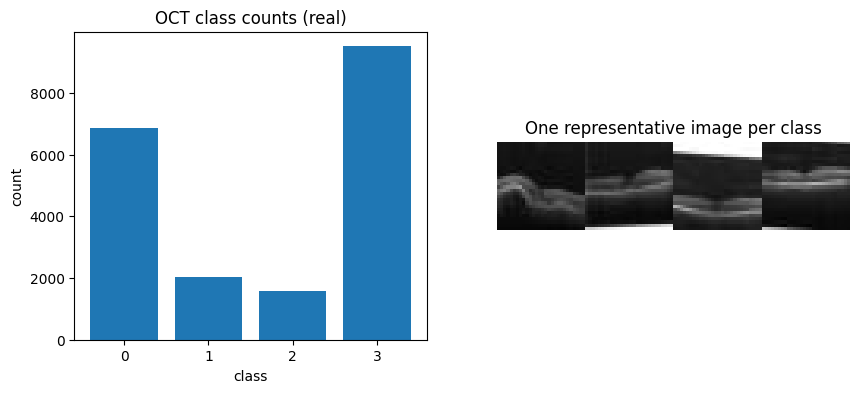

In [16]:
# OCT-02: class counts and representative real images.
uniq, counts = np.unique(oct_labels, return_counts=True)
print("OCTMNIST class distribution (%s):" % OCT_SOURCE)
for u, c in zip(uniq, counts):
    name = OCT_CLASS_NAMES[u] if u < len(OCT_CLASS_NAMES) else "class %d" % u
    print("  class %d (%s): %d" % (u, name, c))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar([str(int(u)) for u in uniq], counts)
ax[0].set_title("OCT class counts (%s)" % ("real" if "SYNTHETIC" not in OCT_SOURCE else "synthetic"))
ax[0].set_xlabel("class"); ax[0].set_ylabel("count")
# Representative real images: one per available class.
show_idx = [int(np.where(oct_labels == u)[0][0]) for u in uniq]
grid = np.stack([oct_imgs_u8[i] for i in show_idx])
gg = np.concatenate(list(grid), axis=1)
ax[1].imshow(gg, cmap="gray"); ax[1].axis("off")
ax[1].set_title("One representative image per class")
save_fig(fig, "oct_class_overview.png")
plt.show()

In [17]:
# Scale images to [-1, 1] for the Tanh generator (identical preprocessing for eval).
def to_model_images(imgs_u8):
    """Convert uint8 N,28,28 to float tensor N,1,28,28 in [-1, 1]."""
    x = torch.tensor(imgs_u8, dtype=torch.float32).unsqueeze(1) / 255.0
    return x * 2.0 - 1.0

oct_x = to_model_images(oct_imgs_u8)
print("OCT model tensor:", tuple(oct_x.shape), "range", float(oct_x.min()), float(oct_x.max()))

OCT model tensor: (20000, 1, 28, 28) range -1.0 1.0


[oct] epoch 0 loss_d 0.3993 loss_g 2.3486
[oct] epoch 1 loss_d 0.4137 loss_g 2.3909
[oct] epoch 2 loss_d 0.4333 loss_g 2.5318
[oct] epoch 3 loss_d 0.4870 loss_g 2.2539
[oct] epoch 4 loss_d 0.5109 loss_g 2.1350
[oct] epoch 5 loss_d 0.5297 loss_g 2.1513
[oct] epoch 6 loss_d 0.6245 loss_g 1.9714
[oct] epoch 7 loss_d 0.6667 loss_g 1.8688
[oct] epoch 8 loss_d 0.7137 loss_g 1.7415
[oct] epoch 9 loss_d 0.7281 loss_g 1.7224
[oct] epoch 10 loss_d 0.7376 loss_g 1.6631
[oct] epoch 11 loss_d 0.7716 loss_g 1.6866
[oct] epoch 12 loss_d 0.7973 loss_g 1.6333
[oct] epoch 13 loss_d 0.7998 loss_g 1.6494
[oct] epoch 14 loss_d 0.7931 loss_g 1.6272
[oct] epoch 15 loss_d 0.7843 loss_g 1.5338
[oct] epoch 16 loss_d 0.8533 loss_g 1.5440
[oct] epoch 17 loss_d 0.8482 loss_g 1.5689
[oct] epoch 18 loss_d 0.8450 loss_g 1.5658
[oct] epoch 19 loss_d 0.8399 loss_g 1.4873
[oct] epoch 20 loss_d 0.8710 loss_g 1.5124
[oct] epoch 21 loss_d 0.8929 loss_g 1.5412
[oct] epoch 22 loss_d 0.8623 loss_g 1.4959
[oct] epoch 23 loss_d

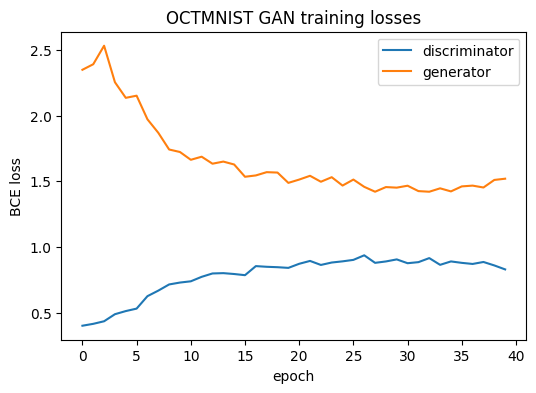

In [18]:
# OCT-03 and OCT-04: train the convolutional GAN and record losses.
oct_gen, oct_disc, oct_hist, oct_progress, oct_fixed = train_image_gan(
    oct_x, CONFIG["image_gan"], seed=PROJECT_SEED, tag="oct")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(oct_hist["epoch"], oct_hist["loss_d"], label="discriminator")
ax.plot(oct_hist["epoch"], oct_hist["loss_g"], label="generator")
ax.set_title("OCTMNIST GAN training losses"); ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss"); ax.legend()
save_fig(fig, "oct_losses.png")
plt.show()

Saved figure: outputs/figures/oct_generated.png


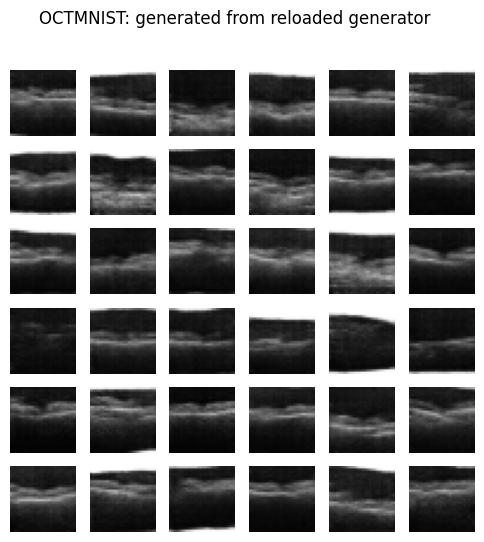

In [19]:
# OCT-05: reload the SAVED generator and generate from it.
oct_gen_reloaded = DCGANGenerator(CONFIG["image_gan"]["latent_dim"]).to(DEVICE)
load_state_into(oct_gen_reloaded, os.path.join(CKPT_DIR, "oct_generator.pt"))
set_seed(PROJECT_SEED)
with torch.no_grad():
    oct_fake = oct_gen_reloaded(torch.randn(64, CONFIG["image_gan"]["latent_dim"], device=DEVICE))
show_image_grid(oct_fake, "OCTMNIST: generated from reloaded generator", "oct_generated.png")

Saved figure: outputs/figures/oct_real_grid.png


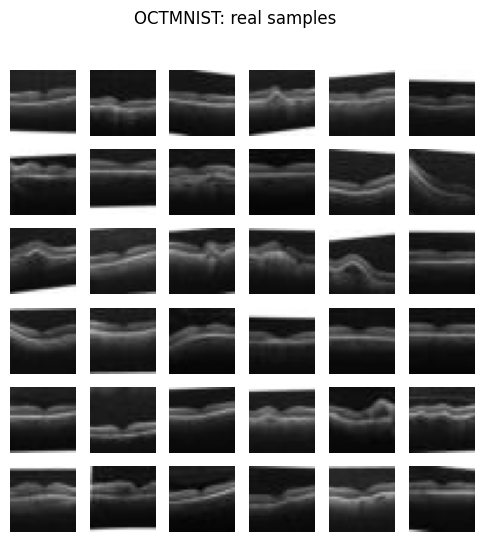

Saved figure: outputs/figures/oct_fake_grid.png


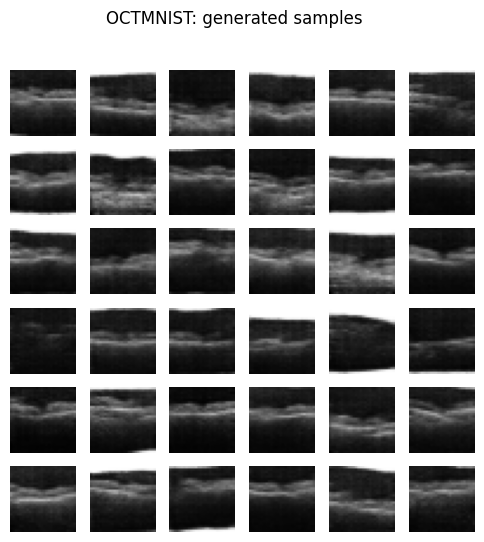

In [20]:
# OCT-06: side by side real versus generated.
set_seed(PROJECT_SEED)
ridx = np.random.choice(oct_x.shape[0], 36, replace=False)
show_image_grid(oct_x[ridx], "OCTMNIST: real samples", "oct_real_grid.png")
show_image_grid(oct_fake, "OCTMNIST: generated samples", "oct_fake_grid.png")

In [27]:
!pip install -q torch-fidelity

import sys
import importlib

# Remove all torchmetrics related modules from sys.modules to ensure a fresh import
for k in list(sys.modules.keys()):
    if k.startswith('torchmetrics'):
        del sys.modules[k]

# Explicitly re-run the _ensure for torchmetrics to make sure the global _tm is refreshed.
# The _ensure function is defined in an earlier cell and should be available.
global _tm # Declare _tm as global to ensure we update the one from cell 264543ec
_tm = _ensure("torchmetrics")

# OCT-07: quantitative FID with a documented protocol.
# Protocol: identical [-1, 1] preprocessing for real and generated; equal sample
# counts; true Inception FID (torchmetrics, feature 2048, RGB by channel repeat) when
# enabled, otherwise the labelled offline proxy. FID values are not compared across
# members because protocol and dataset must match exactly.
n_fid = min(CONFIG["image_gan"]["fid_samples"], oct_x.shape[0])
set_seed(PROJECT_SEED)
real_for_fid = oct_x[np.random.choice(oct_x.shape[0], n_fid, replace=False)]
with torch.no_grad():
    fake_for_fid = oct_gen_reloaded(torch.randn(n_fid, CONFIG["image_gan"]["latent_dim"], device=DEVICE)).cpu()
oct_fid, oct_fid_label = image_fid(real_for_fid, fake_for_fid)
print("OCTMNIST FID: %.3f  metric: %s  (n=%d per set)" % (oct_fid, oct_fid_label, n_fid))
with open(os.path.join(MET_DIR, "oct_fid.json"), "w") as _f:
    json.dump({"fid": oct_fid, "metric": oct_fid_label, "n": n_fid, "source": OCT_SOURCE}, _f, indent=2)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

OCTMNIST FID: 91.323  metric: true Inception FID (torchmetrics, feature 2048)  (n=2048 per set)


## Do the generated retinal images hold up, and are they diagnostic?

The loss curves and the real-versus-generated grids above are the evidence for this task; the report interprets the specific values from a full run. Points to address: whether the generated images reproduce the layered retinal texture, whether artifacts such as checkerboard patterns or blur are visible, and whether any mode collapse is apparent from repeated near-identical samples. The FID value quantifies distributional distance under the stated protocol, but an ImageNet-trained Inception extractor is a weak descriptor for small single-channel medical images, so FID should be read as an indicator rather than an exact quality score, and the offline proxy is only a relative indicator.

These generated images are not diagnostic. They are synthetic textures produced by a GAN and must not be used for any clinical or diagnostic purpose. They carry no patient information and no medical validity.

## Can a tabular GAN reproduce CICIDS 2017 network flows?

## What is the CICIDS 2017 source, scope and licence?

CICIDS 2017 is published by the Canadian Institute for Cybersecurity at the University of New Brunswick and is free for research use with attribution. The core baseline here uses the Wednesday capture, which contains BENIGN traffic and several denial-of-service attack types. The cell tries to download the Wednesday CSV and, if it is not reachable, builds a clearly labelled synthetic tabular fallback with a comparable schema so the notebook still runs. The wording in the brief alternates between DoS and DDoS; the documented core interpretation is Wednesday BENIGN versus DoS, and any all-day expansion is treated as an optional extension that is not attempted here. Preprocessing is leakage-safe: the scaler and PCA are fitted on the training split only.

In [28]:
CIC_FEATURES = ["flow_duration", "total_fwd_packets", "total_bwd_packets",
                "fwd_packet_len_mean", "bwd_packet_len_mean", "flow_bytes_s",
                "flow_packets_s", "flow_iat_mean", "fwd_iat_mean", "bwd_iat_mean",
                "min_packet_len", "max_packet_len", "packet_len_mean",
                "syn_flag_count", "psh_flag_count", "ack_flag_count"]

# Verified public mirror of the real CICIDS 2017 Wednesday capture (no auth). The
# file is downloaded once to a repo-relative path so no manual upload, Kaggle key or
# Drive mount is needed. The synthetic block below is only a download-failure fallback.
CIC_CSV_URL = ("https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/"
               "Wednesday-workingHours.pcap_ISCX.csv")
CIC_CSV_PATH = os.path.join("data", "Wednesday-workingHours.pcap_ISCX.csv")

# Maps the notebook's engineered feature names onto the standard CICIDS column names.
_CIC_COLUMN_MAP = {
    "flow_duration": "Flow Duration",
    "total_fwd_packets": "Total Fwd Packets",
    "total_bwd_packets": "Total Backward Packets",
    "fwd_packet_len_mean": "Fwd Packet Length Mean",
    "bwd_packet_len_mean": "Bwd Packet Length Mean",
    "flow_bytes_s": "Flow Bytes/s",
    "flow_packets_s": "Flow Packets/s",
    "flow_iat_mean": "Flow IAT Mean",
    "fwd_iat_mean": "Fwd IAT Mean",
    "bwd_iat_mean": "Bwd IAT Mean",
    "min_packet_len": "Min Packet Length",
    "max_packet_len": "Max Packet Length",
    "packet_len_mean": "Packet Length Mean",
    "syn_flag_count": "SYN Flag Count",
    "psh_flag_count": "PSH Flag Count",
    "ack_flag_count": "ACK Flag Count",
}

def _load_real_cicids_wednesday(csv_path, max_per_class):
    """Parse the real Wednesday CSV into the notebook's BENIGN vs DoS schema.

    Strips column names, locates the Label column, maps the standard CICIDS column
    names onto the notebook's engineered feature names, and keeps only BENIGN and DoS
    rows so that all DoS variants collapse to the single label DoS. This is data
    acquisition only; the downstream cleaning, split, scaling and filtering are
    unchanged and still operate on CIC_FEATURES and the Label column.
    """
    raw = pd.read_csv(csv_path, low_memory=False)
    raw.columns = [str(c).strip() for c in raw.columns]
    lookup = {c.lower(): c for c in raw.columns}
    label_col = lookup.get("label", raw.columns[-1])
    out = pd.DataFrame()
    for feat in CIC_FEATURES:
        real_name = _CIC_COLUMN_MAP[feat]
        key = real_name.lower()
        if key not in lookup:
            raise RuntimeError("expected CICIDS column not found: " + real_name)
        out[feat] = pd.to_numeric(raw[lookup[key]], errors="coerce")
    labels = raw[label_col].astype(str).str.strip().str.upper()
    mapped = np.where(labels == "BENIGN", "BENIGN",
                      np.where(labels.str.startswith("DOS"), "DoS", "OTHER"))
    out["Label"] = mapped
    out = out[out["Label"].isin(["BENIGN", "DoS"])].reset_index(drop=True)
    parts = [out[out["Label"] == cls].iloc[:max_per_class] for cls in ("BENIGN", "DoS")]
    df = pd.concat(parts, ignore_index=True)
    if df.empty:
        raise RuntimeError("no BENIGN or DoS rows parsed from the Wednesday CSV")
    return df

def load_cicids_wednesday(max_per_class):
    """Return a pandas DataFrame of Wednesday flows with a Label column, plus source.

    Primary path: download the real Wednesday capture once to a repo-relative path and
    parse the BENIGN versus DoS flows. On any failure a clearly labelled synthetic
    tabular fallback is built and is never presented as the real capture.
    """
    if pd is None:
        raise RuntimeError("pandas is required for the CICIDS task")
    # Primary: real Wednesday CSV, auto-downloaded once (no manual upload or key).
    try:
        os.makedirs("data", exist_ok=True)
        if not os.path.exists(CIC_CSV_PATH):
            print("Downloading CICIDS Wednesday CSV (~225 MB, one time)...")
            urllib.request.urlretrieve(CIC_CSV_URL, CIC_CSV_PATH)
        df = _load_real_cicids_wednesday(CIC_CSV_PATH, max_per_class)
        print("Loaded real CICIDS Wednesday capture:", len(df), "rows")
        return df, "CICIDS 2017 Wednesday capture (real, auto-downloaded)"
    except Exception as exc:
        print("Real CICIDS download or parse failed, using synthetic fallback:", exc)
    # Fallback only: labelled synthetic tabular data with a comparable schema.
    print("Using SYNTHETIC CICIDS-like fallback (clearly labelled, not the real capture).")
    set_seed(PROJECT_SEED)
    rows = []
    n = max_per_class
    # BENIGN: smaller flows, moderate rates.
    benign = np.random.lognormal(mean=1.0, sigma=0.8, size=(n, len(CIC_FEATURES)))
    benign[:, 0] *= 500  # flow duration
    # DoS: heavier bursts, higher packet counts and flag counts.
    dos = np.random.lognormal(mean=1.6, sigma=1.0, size=(n, len(CIC_FEATURES)))
    dos[:, 0] *= 200
    dos[:, 1:3] *= 4
    dos[:, 13:16] *= 6
    df_b = pd.DataFrame(benign, columns=CIC_FEATURES); df_b["Label"] = "BENIGN"
    df_d = pd.DataFrame(dos, columns=CIC_FEATURES); df_d["Label"] = "DoS"
    df = pd.concat([df_b, df_d], ignore_index=True)
    # Inject a few missing values, infinities and duplicates to exercise the cleaning.
    df.iloc[0, 0] = np.inf
    df.iloc[1, 1] = np.nan
    df = pd.concat([df, df.iloc[:5]], ignore_index=True)
    return df, "SYNTHETIC fallback (not real CICIDS 2017)"

cic_df, CIC_SOURCE = load_cicids_wednesday(CONFIG["cicids"]["max_per_class"])
print("CICIDS source:", CIC_SOURCE, "| rows:", len(cic_df))

Loaded real CICIDS Wednesday capture: 40000 rows
CICIDS source: CICIDS 2017 Wednesday capture (real, auto-downloaded) | rows: 40000

In [29]:
# CIC-02: schema, missing values, infinities, duplicates and class balance.
print("Schema and dtypes:")
print(cic_df.dtypes)
n_dup = int(cic_df.duplicated().sum())
feat_block = cic_df[CIC_FEATURES]
n_inf = int(np.isinf(feat_block.to_numpy(dtype=float)).sum())
n_nan = int(feat_block.isna().to_numpy().sum())
print("Duplicated rows:", n_dup)
print("Infinite feature cells:", n_inf)
print("Missing feature cells:", n_nan)
print("Class balance:")
print(cic_df["Label"].value_counts())

Schema and dtypes:
flow_duration            int64
total_fwd_packets        int64
total_bwd_packets        int64
fwd_packet_len_mean    float64
bwd_packet_len_mean    float64
flow_bytes_s           float64
flow_packets_s         float64
flow_iat_mean          float64
fwd_iat_mean           float64
bwd_iat_mean           float64
min_packet_len           int64
max_packet_len           int64
packet_len_mean        float64
syn_flag_count           int64
psh_flag_count           int64
ack_flag_count           int64
Label                   object
dtype: object
Duplicated rows: 5002
Infinite feature cells: 69
Missing feature cells: 35
Class balance:
Label
BENIGN    20000
DoS       20000
Name: count, dtype: int64


In [30]:
# CIC-03 and CIC-04: build the Wednesday BENIGN vs DoS subset, clean, then split and
# fit the scaler on the training split only (leakage safe).
def clean_cicids(df):
    """Drop duplicates, replace infinities, impute missing values with train later."""
    df = df.drop_duplicates().reset_index(drop=True)
    X = np.array(df[CIC_FEATURES].to_numpy(dtype=np.float64), copy=True)
    X[np.isinf(X)] = np.nan
    y = (df["Label"].to_numpy() == "DoS").astype(int)  # 1 = DoS, 0 = BENIGN
    return X, y

X_all, y_all = clean_cicids(cic_df)
# Train test split before fitting any statistics.
set_seed(PROJECT_SEED)
perm = np.random.permutation(X_all.shape[0])
cut = int(0.8 * len(perm))
tr, te = perm[:cut], perm[cut:]
X_tr_raw, X_te_raw = X_all[tr], X_all[te]
y_tr, y_te = y_all[tr], y_all[te]

# Impute missing values using TRAIN medians only, then scale using TRAIN stats only.
train_median = np.nanmedian(X_tr_raw, axis=0)
def impute(X):
    X = X.copy()
    inds = np.where(np.isnan(X))
    X[inds] = np.take(train_median, inds[1])
    return X
X_tr_imp, X_te_imp = impute(X_tr_raw), impute(X_te_raw)

if _sk is not None:
    scaler = StandardScaler().fit(X_tr_imp)  # fit on train only (CIC-04)
    X_tr = scaler.transform(X_tr_imp)
    X_te = scaler.transform(X_te_imp)
else:
    mu, sd = X_tr_imp.mean(0), X_tr_imp.std(0) + 1e-8
    X_tr = (X_tr_imp - mu) / sd
    X_te = (X_te_imp - mu) / sd

# The GAN models the DoS attack flows (the minority class of operational interest).
X_tr_dos = X_tr[y_tr == 1]
print("Train DoS matrix for the GAN:", X_tr_dos.shape)

Train DoS matrix for the GAN: (13944, 16)


## How does the GAN generate feature vectors instead of images?

The generator and discriminator are multilayer perceptrons operating on the scaled feature vectors, not on images. The generator output is linear because the data are standardised to roughly zero mean and unit variance rather than bounded to [-1, 1].

In [31]:
class TabularGenerator(nn.Module):
    """MLP generator producing standardised feature vectors."""
    def __init__(self, latent_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.BatchNorm1d(64), nn.LeakyReLU(0.2),
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class TabularDiscriminator(nn.Module):
    """MLP discriminator for feature vectors with a sigmoid output."""
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

def train_tabular_gan(data, cfg, seed, tag):
    """Train the tabular GAN on standardised feature vectors."""
    set_seed(seed)
    tens = torch.tensor(data, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(tens),
        batch_size=min(cfg["batch_size"], max(8, len(tens))), shuffle=True, drop_last=True)
    latent_dim, out_dim = cfg["latent_dim"], data.shape[1]
    gen = TabularGenerator(latent_dim, out_dim).to(DEVICE)
    disc = TabularDiscriminator(out_dim).to(DEVICE)
    loss_fn = nn.BCELoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=cfg["lr"], betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=cfg["lr"], betas=(0.5, 0.999))
    hist = {"epoch": [], "loss_d": [], "loss_g": []}
    for epoch in range(cfg["epochs"]):
        ld = lg = 0.0; nb = 0
        for (real,) in loader:
            real = real.to(DEVICE); bs = real.shape[0]
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z).detach()
            disc.zero_grad()
            loss_d = loss_fn(disc(real), torch.ones(bs, 1, device=DEVICE)) + \
                     loss_fn(disc(fake), torch.zeros(bs, 1, device=DEVICE))
            loss_d.backward(); opt_d.step()
            for p in disc.parameters():
                p.requires_grad_(False)
            z = torch.randn(bs, latent_dim, device=DEVICE)
            gen.zero_grad()
            loss_g = loss_fn(disc(gen(z)), torch.ones(bs, 1, device=DEVICE))
            loss_g.backward(); opt_g.step()
            for p in disc.parameters():
                p.requires_grad_(True)
            ld += check_finite(loss_d, "loss_d"); lg += check_finite(loss_g, "loss_g"); nb += 1
        hist["epoch"].append(epoch); hist["loss_d"].append(ld / nb); hist["loss_g"].append(lg / nb)
        if epoch % max(1, cfg["epochs"] // 5) == 0 or epoch == cfg["epochs"] - 1:
            print("[%s] epoch %d loss_d %.4f loss_g %.4f" % (tag, epoch, ld / nb, lg / nb))
    save_checkpoint(gen, os.path.join(CKPT_DIR, "%s_generator.pt" % tag),
                    {"task": tag, "seed": seed, "latent_dim": latent_dim, "n_features": out_dim})
    np.savez(os.path.join(MET_DIR, "%s_losses.npz" % tag),
             **{k: np.array(v) for k, v in hist.items()})
    return gen, hist

cic_gen, cic_hist = train_tabular_gan(X_tr_dos, CONFIG["cicids"], seed=PROJECT_SEED, tag="cicids")

[cicids] epoch 0 loss_d 1.3220 loss_g 0.6255
[cicids] epoch 24 loss_d 1.1245 loss_g 1.0354
[cicids] epoch 48 loss_d 1.1509 loss_g 1.0301
[cicids] epoch 72 loss_d 1.1734 loss_g 0.9956
[cicids] epoch 96 loss_d 1.1670 loss_g 0.9758
[cicids] epoch 119 loss_d 1.1767 loss_g 0.9804


Saved figure: outputs/figures/cicids_losses.png


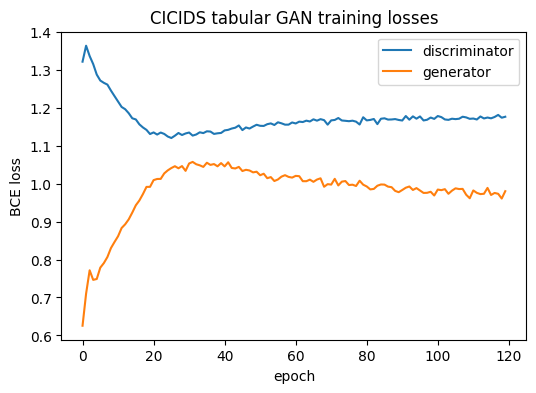

In [32]:
# CIC-06: loss curves.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cic_hist["epoch"], cic_hist["loss_d"], label="discriminator")
ax.plot(cic_hist["epoch"], cic_hist["loss_g"], label="generator")
ax.set_title("CICIDS tabular GAN training losses")
ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
save_fig(fig, "cicids_losses.png")
plt.show()

In [33]:
# Generate DoS-like feature vectors from the saved and reloaded generator.
cic_gen_reloaded = TabularGenerator(CONFIG["cicids"]["latent_dim"], X_tr_dos.shape[1]).to(DEVICE)
load_state_into(cic_gen_reloaded, os.path.join(CKPT_DIR, "cicids_generator.pt"))
n_eval = min(CONFIG["cicids"]["eval_samples"], X_tr_dos.shape[0])
set_seed(PROJECT_SEED)
with torch.no_grad():
    cic_fake = cic_gen_reloaded(torch.randn(n_eval, CONFIG["cicids"]["latent_dim"], device=DEVICE)).cpu().numpy()
real_dos_eval = X_tr_dos[np.random.choice(X_tr_dos.shape[0], n_eval, replace=True)]

Saved figure: outputs/figures/cicids_pca.png


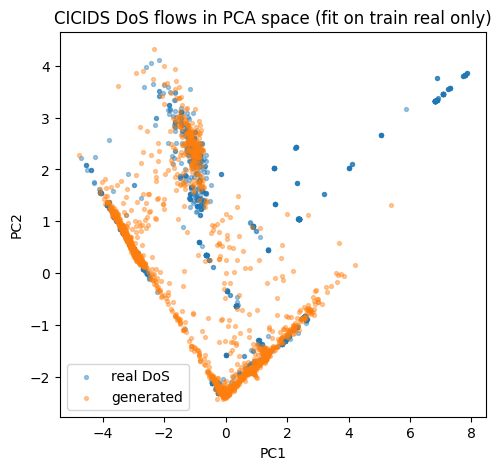

In [34]:
# CIC-07: PCA projection with consistent preprocessing. PCA is fit on the TRAIN DoS
# real data only, then applied to both real and generated data (leakage safe).
if _sk is not None:
    pca = PCA(n_components=2).fit(X_tr_dos)
    real_p = pca.transform(real_dos_eval)
    fake_p = pca.transform(cic_fake)
else:
    mu_pca = X_tr_dos.mean(0)
    _, _, Vt = np.linalg.svd(X_tr_dos - mu_pca, full_matrices=False)
    real_p = (real_dos_eval - mu_pca) @ Vt[:2].T
    fake_p = (cic_fake - mu_pca) @ Vt[:2].T

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(real_p[:, 0], real_p[:, 1], s=8, alpha=0.4, label="real DoS")
ax.scatter(fake_p[:, 0], fake_p[:, 1], s=8, alpha=0.4, label="generated")
ax.set_title("CICIDS DoS flows in PCA space (fit on train real only)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()
save_fig(fig, "cicids_pca.png")
plt.show()

## Do the generated flows match the real ones and stay in a valid domain?

Beyond the projection, two quantitative checks are reported. First, the mean per-feature 1D Wasserstein distance between real and generated values in the original (unscaled) feature space, which is zero for a perfect match. Second, the Frobenius norm of the difference between the real and generated feature correlation matrices, which measures how well pairwise dependencies are reproduced. A valid-domain check reports the fraction of generated flows whose non-negative features (durations, counts, rates) are non-negative after inverse scaling, since negative values are physically invalid for those columns.

In [35]:
def inverse_scale(Xs):
    """Map standardised vectors back to the original feature space."""
    if _sk is not None:
        return scaler.inverse_transform(Xs)
    return Xs * sd + mu

real_orig = inverse_scale(real_dos_eval)
fake_orig = inverse_scale(cic_fake)

# Mean per-feature Wasserstein distance.
if _scipy is not None:
    from scipy.stats import wasserstein_distance
    wdists = [wasserstein_distance(real_orig[:, j], fake_orig[:, j]) for j in range(real_orig.shape[1])]
    mean_w = float(np.mean(wdists))
else:
    mean_w = float(np.mean(np.abs(np.sort(real_orig, 0) - np.sort(fake_orig, 0))))

# Correlation matrix error.
corr_real = np.corrcoef(real_orig, rowvar=False)
corr_fake = np.corrcoef(fake_orig, rowvar=False)
corr_err = float(np.linalg.norm(np.nan_to_num(corr_real - corr_fake)))

# Valid domain fraction: features that should be non-negative.
nonneg_cols = list(range(real_orig.shape[1]))  # all engineered features are non-negative
valid_frac = float((fake_orig[:, nonneg_cols] >= 0).all(axis=1).mean())

cic_metrics = {"mean_feature_wasserstein": mean_w, "correlation_frobenius_error": corr_err,
               "valid_domain_fraction": valid_frac, "source": CIC_SOURCE, "n_eval": n_eval}
with open(os.path.join(MET_DIR, "cicids_metrics.json"), "w") as _f:
    json.dump(cic_metrics, _f, indent=2)
print("CICIDS quantitative alignment:")
print(json.dumps(cic_metrics, indent=2))

CICIDS quantitative alignment:
{
  "mean_feature_wasserstein": 1328472.168666401,
  "correlation_frobenius_error": 5.281907881260235,
  "valid_domain_fraction": 0.0035,
  "source": "CICIDS 2017 Wednesday capture (real, auto-downloaded)",
  "n_eval": 2000
}


## What do the alignment measures say, and what do they not prove?

The PCA projection and the two quantitative measures above describe how closely the generated DoS flows match the real DoS flows under a leakage-safe protocol; the report interprets the specific values from a full run. The projection is a visual aid only and is not a score, which is why the Wasserstein and correlation measures are reported alongside it. Limitations to discuss include mode coverage across DoS variants, whether generated rows satisfy feature constraints, and instability of GAN training on heavy-tailed tabular features.

No claim is made that these synthetic flows are private, safe, or operationally useful. Distribution similarity does not establish privacy, does not guarantee that a downstream detector trained on this data would generalise, and does not imply any fitness for deployment. Any such use would require separate and dedicated evaluation that is outside the scope of this notebook.

## Do generated cake sketches capture the real strokes?

## Where do the QuickDraw sketches come from?

The Quick, Draw! dataset is released by Google under a Creative Commons Attribution 4.0 licence. The simplified numpy bitmap format stores each sketch as a 28 by 28 grayscale image. The cell downloads the `birthday cake` bitmap file and falls back to a clearly labelled synthetic sketch set if the download is unavailable. The fallback is never presented as real QuickDraw data.

In [36]:
def load_quickdraw_cake(max_n):
    """Return (images_uint8 N,28,28, source_label) for QuickDraw birthday cake."""
    try:
        url = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
               "birthday%20cake.npy")
        with urllib.request.urlopen(url, timeout=30) as r:
            blob = io.BytesIO(r.read())
        arr = np.load(blob)  # shape N,784, uint8
        arr = arr[:max_n].reshape(-1, 28, 28)
        return arr, "QuickDraw birthday cake (official numpy bitmap)"
    except Exception as exc:
        print("QuickDraw download failed:", exc)
    print("Using SYNTHETIC cake-like fallback (clearly labelled, not real QuickDraw).")
    set_seed(PROJECT_SEED)
    n = min(max_n, 2000)
    imgs = np.zeros((n, 28, 28), dtype=np.uint8)
    for i in range(n):
        img = np.zeros((28, 28))
        base = np.random.randint(16, 20)
        width = np.random.randint(10, 18)
        x0 = np.random.randint(4, 8)
        img[base:base + 6, x0:x0 + width] = 255  # cake body
        n_candles = np.random.randint(2, 5)
        for c in range(n_candles):
            cx = x0 + int((c + 0.5) * width / n_candles)
            img[base - 5:base, cx:cx + 1] = 255  # candle
            img[base - 6, cx] = 255  # flame
        img = np.clip(img + np.random.randn(28, 28) * 8, 0, 255)
        imgs[i] = img.astype(np.uint8)
    return imgs, "SYNTHETIC fallback (not real QuickDraw)"

qd_imgs_u8, QD_SOURCE = load_quickdraw_cake(CONFIG["image_gan"]["max_train"])
print("QuickDraw source:", QD_SOURCE, "| shape:", qd_imgs_u8.shape)

QuickDraw source: QuickDraw birthday cake (official numpy bitmap) | shape: (20000, 28, 28)


Saved figure: outputs/figures/qd_real_grid.png


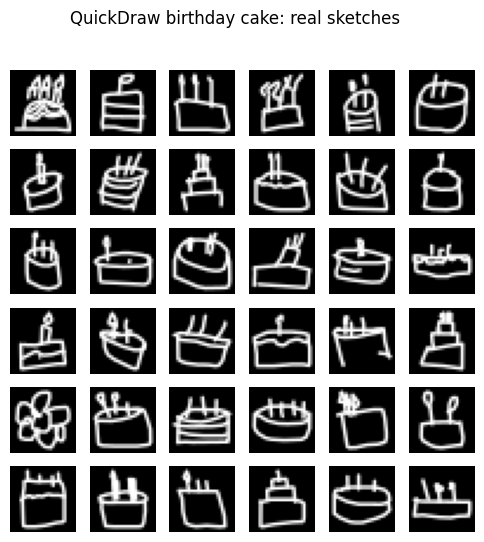

In [37]:
# QD-02: representative real sketches.
set_seed(PROJECT_SEED)
qd_x = to_model_images(qd_imgs_u8)
ridx = np.random.choice(qd_x.shape[0], 36, replace=False)
show_image_grid(qd_x[ridx], "QuickDraw birthday cake: real sketches", "qd_real_grid.png")

[qd] epoch 0 loss_d 0.1460 loss_g 3.7623
[qd] epoch 1 loss_d 0.3393 loss_g 3.0185
[qd] epoch 2 loss_d 0.5577 loss_g 2.0013
[qd] epoch 3 loss_d 0.5592 loss_g 1.8379
[qd] epoch 4 loss_d 0.4528 loss_g 2.1143
[qd] epoch 5 loss_d 0.3285 loss_g 2.4370
[qd] epoch 6 loss_d 0.3013 loss_g 2.6217
[qd] epoch 7 loss_d 0.2469 loss_g 2.7717
[qd] epoch 8 loss_d 0.2823 loss_g 2.8575
[qd] epoch 9 loss_d 0.2888 loss_g 2.7524
[qd] epoch 10 loss_d 0.2924 loss_g 2.9326
[qd] epoch 11 loss_d 0.2986 loss_g 3.0642
[qd] epoch 12 loss_d 0.1827 loss_g 3.0143
[qd] epoch 13 loss_d 0.2450 loss_g 3.2519
[qd] epoch 14 loss_d 0.1406 loss_g 3.3582
[qd] epoch 15 loss_d 0.3277 loss_g 3.1075
[qd] epoch 16 loss_d 0.1090 loss_g 3.6389
[qd] epoch 17 loss_d 0.3581 loss_g 3.0906
[qd] epoch 18 loss_d 0.1203 loss_g 3.4816
[qd] epoch 19 loss_d 0.2859 loss_g 3.8935
[qd] epoch 20 loss_d 0.1760 loss_g 3.2129
[qd] epoch 21 loss_d 0.2662 loss_g 3.2298
[qd] epoch 22 loss_d 0.0999 loss_g 3.8521
[qd] epoch 23 loss_d 0.6830 loss_g 3.6200
[q

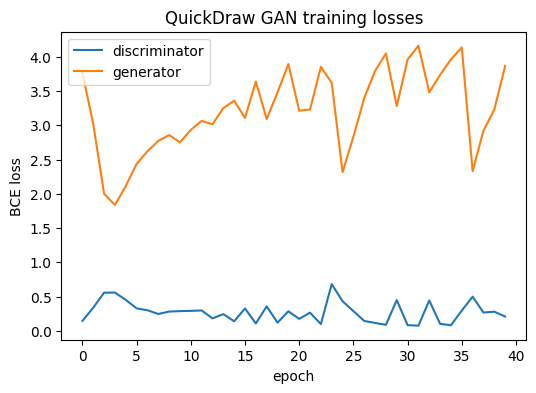

In [38]:
# QD-03 and QD-04: train the DCGAN, record losses and fixed noise progress grids.
qd_gen, qd_disc, qd_hist, qd_progress, qd_fixed = train_image_gan(
    qd_x, CONFIG["image_gan"], seed=PROJECT_SEED, tag="qd")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(qd_hist["epoch"], qd_hist["loss_d"], label="discriminator")
ax.plot(qd_hist["epoch"], qd_hist["loss_g"], label="generator")
ax.set_title("QuickDraw GAN training losses")
ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
save_fig(fig, "qd_losses.png")
plt.show()

Saved figure: outputs/figures/qd_progress.png


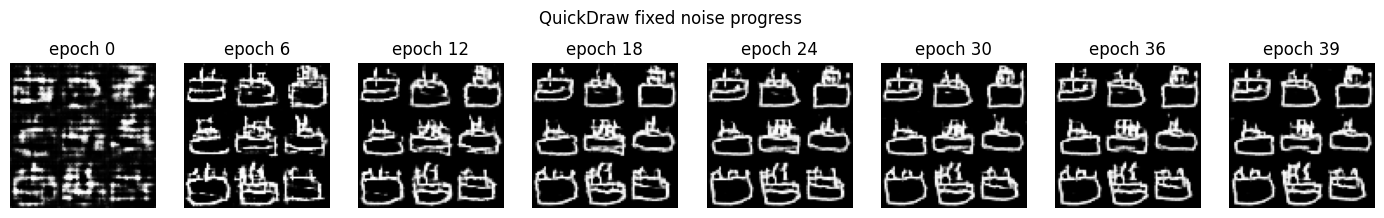

In [39]:
# QD-04: fixed noise progress across epochs (same latent noise each snapshot).
n_snap = len(qd_progress)
fig, axes = plt.subplots(1, n_snap, figsize=(2.2 * n_snap, 2.6))
if n_snap == 1:
    axes = [axes]
for ax, (ep, grid) in zip(axes, qd_progress):
    g = ((grid[:9].clamp(-1, 1) + 1) / 2).numpy()
    tile = np.concatenate([np.concatenate([g[r * 3 + c, 0] for c in range(3)], axis=1)
                           for r in range(3)], axis=0)
    ax.imshow(tile, cmap="gray"); ax.axis("off"); ax.set_title("epoch %d" % ep)
fig.suptitle("QuickDraw fixed noise progress")
save_fig(fig, "qd_progress.png")
plt.show()

Saved figure: outputs/figures/qd_generated.png


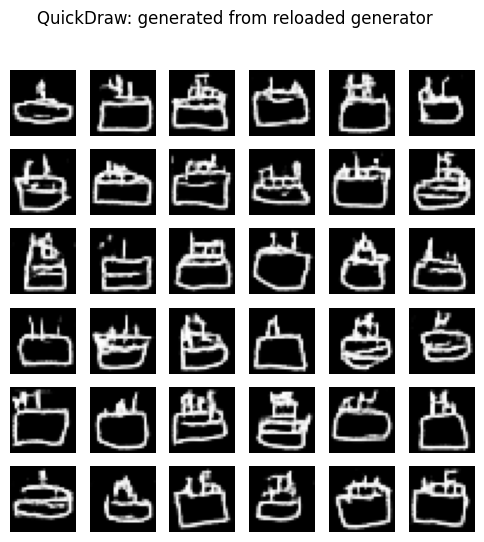

In [40]:
# QD-05: reload the SAVED generator and generate from it.
qd_gen_reloaded = DCGANGenerator(CONFIG["image_gan"]["latent_dim"]).to(DEVICE)
load_state_into(qd_gen_reloaded, os.path.join(CKPT_DIR, "qd_generator.pt"))
set_seed(PROJECT_SEED)
with torch.no_grad():
    qd_fake = qd_gen_reloaded(torch.randn(36, CONFIG["image_gan"]["latent_dim"], device=DEVICE))
show_image_grid(qd_fake, "QuickDraw: generated from reloaded generator", "qd_generated.png")

Saved figure: outputs/figures/qd_real_vs_fake.png


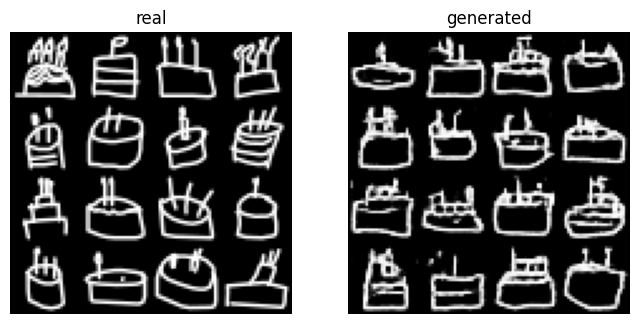

In [41]:
# QD-06: real versus generated side by side is provided by the two grids above; here a
# combined view for direct comparison.
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
def _mosaic(t):
    g = ((t[:16].clamp(-1, 1) + 1) / 2).cpu().numpy()
    return np.concatenate([np.concatenate([g[r * 4 + c, 0] for c in range(4)], axis=1)
                           for r in range(4)], axis=0)
ax[0].imshow(_mosaic(qd_x[ridx]), cmap="gray"); ax[0].axis("off"); ax[0].set_title("real")
ax[1].imshow(_mosaic(qd_fake), cmap="gray"); ax[1].axis("off"); ax[1].set_title("generated")
save_fig(fig, "qd_real_vs_fake.png")
plt.show()

In [42]:
# QD-07: FID with the documented protocol (same helper and protocol as OCTMNIST).
n_fid = min(CONFIG["image_gan"]["fid_samples"], qd_x.shape[0])
set_seed(PROJECT_SEED)
real_for_fid = qd_x[np.random.choice(qd_x.shape[0], n_fid, replace=False)]
with torch.no_grad():
    fake_for_fid = qd_gen_reloaded(torch.randn(n_fid, CONFIG["image_gan"]["latent_dim"], device=DEVICE)).cpu()
qd_fid, qd_fid_label = image_fid(real_for_fid, fake_for_fid)
print("QuickDraw FID: %.3f  metric: %s  (n=%d per set)" % (qd_fid, qd_fid_label, n_fid))
with open(os.path.join(MET_DIR, "qd_fid.json"), "w") as _f:
    json.dump({"fid": qd_fid, "metric": qd_fid_label, "n": n_fid, "source": QD_SOURCE}, _f, indent=2)

QuickDraw FID: 34.749  metric: true Inception FID (torchmetrics, feature 2048)  (n=2048 per set)
